<a href="https://colab.research.google.com/github/project-ida/arpa-e-experiments/blob/main/2024-08-29-palladium-foil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; <a href="https://nbviewer.jupyter.org/github/project-ida/arpa-e-experiments/blob/main/2024-08-29-palladium-foil.ipynb" target="_parent"><img src="https://nbviewer.jupyter.org/static/img/nav_logo.svg" alt="Open In nbviewer" width="100"/></a>

# 2024-09-16 Palladium foil (annealed)

A xy mg annealed palladium foil is gas loaded with deuterium, in a 0.19L chamber.

In [ ]:
# RUN THIS IF YOU ARE USING GOOGLE COLAB
import sys
import os
!git clone https://github.com/project-ida/arpa-e-experiments.git
sys.path.insert(0,'/content/arpa-e-experiments')
os.chdir('/content/arpa-e-experiments')

In [4]:
# Libraries and helper functions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import Image
from IPython.display import Video
from IPython.display import HTML

# Use our custom helper functions
# - process_data
# - plot_panels
from libs.helpers import *

In [5]:
# This will go into the title of all plots
experiment_descriptor = "Annealed palladium foil"

## Reading the raw data

### Temperature

In [18]:
# Read the temperature data
temperature_df = pd.read_csv(
    'data/20240916_201028_Pd_annealed_run_4_cycles_temperatures_extratime.csv',
    parse_dates=['time'],
    date_format="ISO8601",
    index_col='time'
)

In [19]:
# When does data collection begin and end
print(f"Start: {temperature_df.index[0]}, End: {temperature_df.index[-1]}")

Start: 2024-09-16 20:10:00, End: 2024-09-23 09:44:58


In [20]:
# How many data points do we have
raw_total_temperature_points = len(temperature_df)
print(raw_total_temperature_points)

428307


In [21]:
# What's the average time in seconds time between data points
((temperature_df.index[-1] - temperature_df.index[0]) / raw_total_temperature_points).total_seconds()

1.324512

In [22]:
# Count problem values like NaNs
temperature_df.isna().sum()

Thermocouple1Ch1         0
Thermocouple1Ch2         2
Thermocouple1Ch3        75
Thermocouple1Ch4    428307
dtype: int64

`Thermocouple1Ch4` was offline for the whole experiment so we'll drop it.

`Thermocouple1Ch2` and `Thermocouple1Ch3` have a few NaN which we'll fix this during the processing stage.

In [23]:
temperature_df.drop('Thermocouple1Ch4', axis=1, inplace=True) # Drop Thermocouple1Ch4

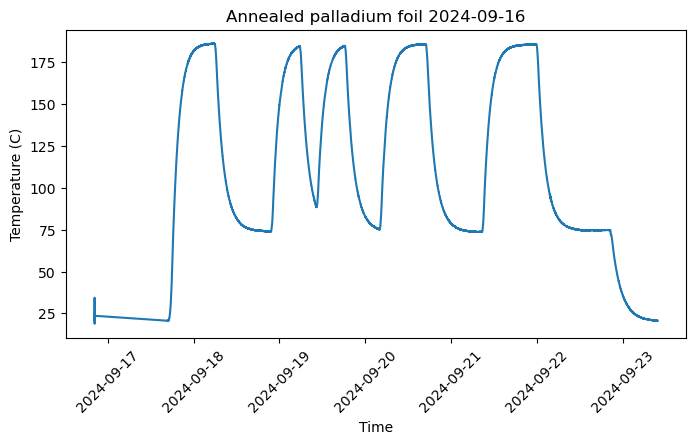

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(temperature_df['Thermocouple1Ch1'])
plt.xlabel('Time')
plt.ylabel('Temperature (C)')
plt.xticks(rotation=45)
plt.title(f"{experiment_descriptor} {temperature_df.index[0].date()}")
plt.show()

### Heating power

In [25]:
# Read the heating power data
heating_df = pd.read_csv(
    'data/20240916_201028_Pd_annealed_run_4_cycles_powersupply_extratime.csv',
    parse_dates=['time'],
    date_format="ISO8601",
    index_col='time'
)

In [26]:
# When does data collection begin and end
print(f"Start: {heating_df.index[0]}, End: {heating_df.index[-1]}")

Start: 2024-09-16 20:10:00, End: 2024-09-23 09:44:59


In [27]:
# How many data points do we have
raw_total_heating_points = len(heating_df)
print(raw_total_heating_points)

184783


In [28]:
# What's the average time in seconds time between data points
((heating_df.index[-1] - heating_df.index[0]) / raw_total_heating_points).total_seconds()

3.070082

In [29]:
# Count problem values like NaNs
heating_df.isna().sum()

Voltage    0
Current    0
dtype: int64

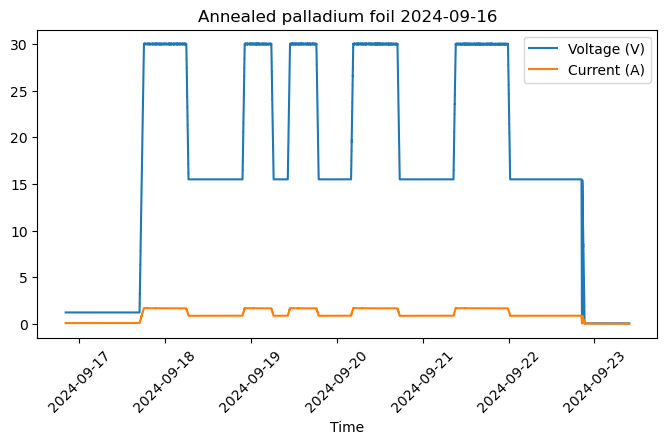

In [30]:
plt.figure(figsize=(8, 4))
plt.plot(heating_df['Voltage'], label="Voltage (V)")
plt.plot(heating_df['Current'], label="Current (A)")
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.legend()
plt.title(f"{experiment_descriptor} {heating_df.index[0].date()}")
plt.show()

### Pressure

In [41]:
# Read the pressure data
pressure_df = pd.read_csv(
    'data/20240916_201028_Pd_annealed_run_4_cycles-plus.csv',
    names=['time', 'Voltage1', 'Voltage2', 'Voltage3', 'Voltage4'],
    parse_dates=['time'],
    date_format="ISO8601",
    index_col='time',
    header=None
)

In [42]:
# When does data collection begin and end
print(f"Start: {pressure_df.index[0]}, End: {pressure_df.index[-1]}")

Start: 2024-09-16 20:10:30, End: 2024-09-23 09:46:39


In [43]:
# How many data points do we have
raw_total_pressure_points = len(pressure_df)
print(raw_total_pressure_points)

563957


In [44]:
# What's the average time in seconds time between data points
((pressure_df.index[-1] - pressure_df.index[0]) / raw_total_pressure_points).total_seconds()

1.00605

In [45]:
# Count problem values like NaNs
pressure_df.isna().sum()

Voltage1    0
Voltage2    0
Voltage3    0
Voltage4    0
dtype: int64

In [46]:
pressure_df.head()

,Voltage1,Voltage2,Voltage3,Voltage4
time,,,,
2024-09-16 20:10:30,1.854708,0.003598,0.003290,0.002982
2024-09-16 20:10:31,1.858710,0.003905,0.002674,0.002674
2024-09-16 20:10:32,1.856247,0.003598,0.002674,0.002674
2024-09-16 20:10:33,1.854708,0.003290,0.002982,0.002674
2024-09-16 20:10:34,1.856555,0.002982,0.002982,0.002674


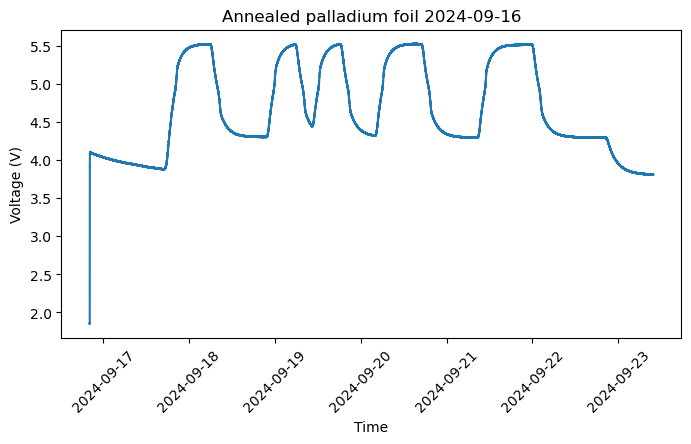

In [47]:
plt.figure(figsize=(8, 4))
plt.plot(pressure_df['Voltage1'])
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.xticks(rotation=45)
plt.title(f"{experiment_descriptor} {pressure_df.index[0].date()}")
plt.show()

## Processing the data

### Corrupt data

There is a large spike in the pressure data at the start of the experiment. We can identify the precise time be seeing where the voltage changes by more than 0.5 over a single measurement.

In [49]:
pressure_df[pressure_df['Voltage1'].diff().abs() > 0.5]

,Voltage1,Voltage2,Voltage3,Voltage4
time,,,,
2024-09-16 20:12:51,3.066210,0.004521,0.003290,0.002982
2024-09-16 20:12:52,3.700894,0.004521,0.002982,0.002982


Let's zoom in to this region

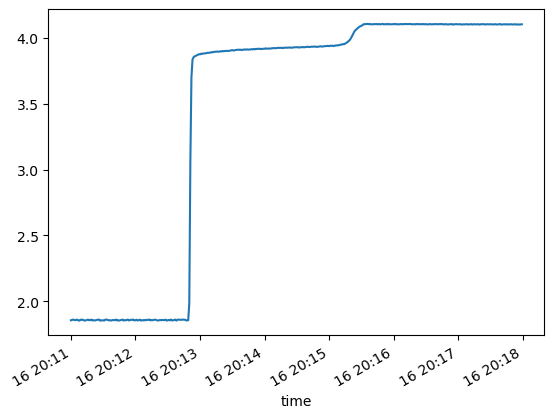

In [99]:
pressure_df['Voltage1']['2024-09-16 20:11':'2024-09-16 20:17'].plot();

This looks less like corrupt data and more like when the chamber was suddenly filled with gas at the start of the experiment. We'll therefore keep this data for now, but we'll want to modify the range of data to exclude the pre-fill stage later on.

### Combining data

To derive physical quantities from several diagnostics, we need to have simultaneous measurements. We'll therefore need to do some interpolation of the data. This is going to involve:
1. Mapping all measurements to the nearest second
2. Selecting overlapping time intervals from the data
3. Combining the data from all diagnostics into one dataframe
4. Interpolate to fill the NaNs that result from combining the data in step 3
5. Drop any NaNs that can sometimes be generated at the edges of the time range

In [51]:
combined_df = process_data(temperature_df, pressure_df,heating_df)

In [52]:
combined_df.head()

,Thermocouple1Ch1,Thermocouple1Ch2,Thermocouple1Ch3,Voltage1,Voltage2,Voltage3,Voltage4,Voltage,Current
time,,,,,,,,,
2024-09-16 20:10:31,21.459664,21.074232,20.946748,1.858710,0.003905,0.002674,0.002674,1.21,0.07
2024-09-16 20:10:32,21.463564,21.079504,20.914176,1.856247,0.003598,0.002674,0.002674,1.21,0.07
2024-09-16 20:10:33,21.465430,21.088877,20.848263,1.854708,0.003290,0.002982,0.002674,1.21,0.07
2024-09-16 20:10:34,21.416286,21.084432,21.036793,1.856555,0.002982,0.002982,0.002674,1.21,0.07
2024-09-16 20:10:35,21.404816,21.080793,21.051352,1.858710,0.003290,0.003290,0.002674,1.21,0.07


We'll now exclude the pre-fill stage to make loading analysis more straightforward later.

In [100]:
combined_df = combined_df['2024-09-16 20:17:00':]

### Pressure readings
The next processing step involves converting the Voltage measurement into a pressure value.

In [101]:
# Constants required to convert pressure gauge voltage into a pressure reading in bar
Resistor = 650  # resistance in Ohms
current_offset_mA = 4  # 4 mA corresponds to 0 bar
pressure_range_bar = 7  # Range is from 0 to 7 bar
current_range_mA = 16  # From 4 mA to 20 mA, so the range is 16 mA

# Calculating current in amperes
pressure_sensor_current = combined_df['Voltage1'] / Resistor

# Calculating pressure in bars
combined_df['pressure_bar'] = 1 + ((pressure_sensor_current * 1000 - current_offset_mA) * pressure_range_bar) / current_range_mA

### Heating power
The next step is calculating the heating power 

In [102]:
combined_df['power'] = combined_df['Voltage']*combined_df['Current']

### Inferring deuterium loading

The deuterium loading is inferred by using the ideal gas law to calculate how many deuterium molecules are present in the gas over time:

$$N_{D_2} = \frac{PV}{k_B T}$$

and associating any changes $\Delta N_{D_2}$ with deuteium entering the lattice. We can then calculate the loading based on the number of lattice atoms $N_{lattice}$:

$$N_{lattice} = 2.19\times 10^{21}$$

The loading is then:

$$2\frac{\Delta N_{D_2}}{N_{lattice}}$$

The factor 2 arrises because a single $D_2$ molecule becomes 2 deuterons once inside the lattice.

In [103]:
# Constants
V = 0.19 / 1000  # Volume of the container in m^3
kB = 1.3806503e-23  # Boltzmann constant in J/K
N_lattice = 2.19e21

In [104]:
combined_df['deuterium_molecules'] = (combined_df['pressure_bar']*1e5 * V) / (kB * (combined_df['Thermocouple1Ch1'] + 273.15))

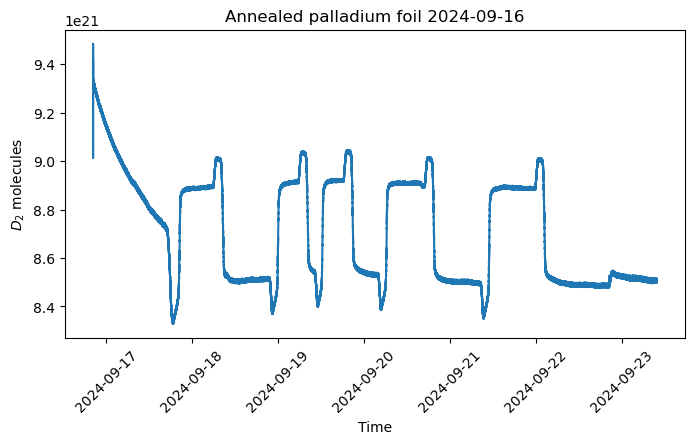

In [105]:
plt.figure(figsize=(8, 4))
plt.plot(combined_df['deuterium_molecules'])
plt.xlabel('Time')
plt.ylabel('$D_2$ molecules')
plt.xticks(rotation=45)
plt.title(f"{experiment_descriptor} {combined_df.index[0].date()}")
plt.show()

Because the gas loading into the chamber started after $t=0$ in the data, we need to shift the reference point for the calculation of $\Delta N_{D_2}$.

In [106]:
combined_df['loading'] = 2*(combined_df.iloc[0]['deuterium_molecules'] - combined_df['deuterium_molecules']) / N_lattice

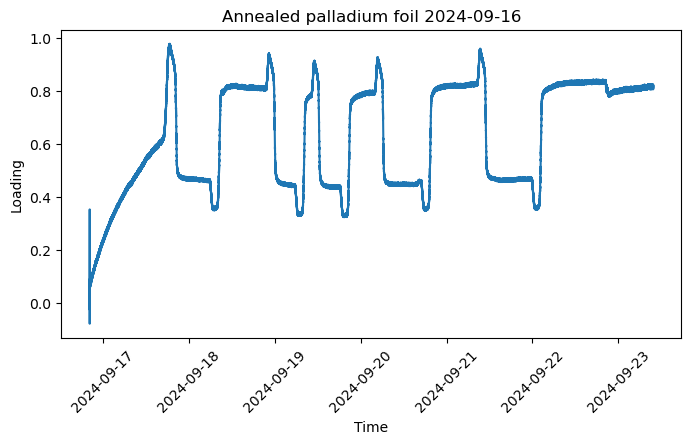

In [107]:
plt.figure(figsize=(8, 4))
plt.plot(combined_df['loading'])
plt.xlabel('Time')
plt.ylabel('Loading')
plt.xticks(rotation=45)
plt.title(f"{experiment_descriptor} {combined_df.index[0].date()}")
plt.show()

## Visualising the data

Let's look at the whole data range first

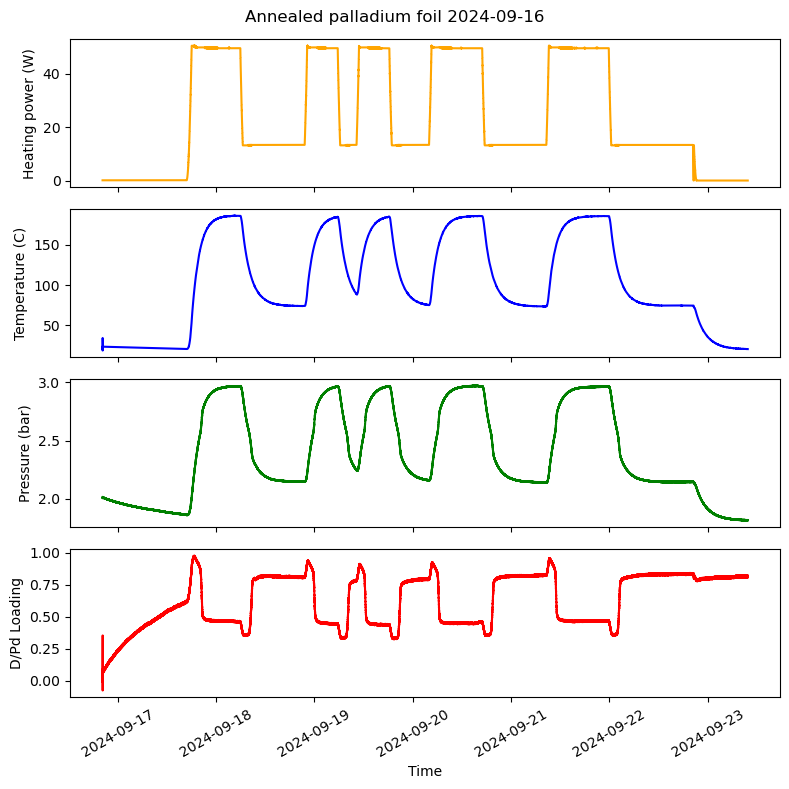

In [108]:
fig, axes = plot_panels(combined_df, ['power','Thermocouple1Ch1', 'pressure_bar', 'loading'],
                        colors=['orange','blue', 'green', 'red'])

axes[0].set_ylabel("Heating power (W)")
axes[1].set_ylabel("Temperature (C)")
axes[2].set_ylabel("Pressure (bar)")
axes[3].set_ylabel("D/Pd Loading")
fig.suptitle(f"{experiment_descriptor} {combined_df.index[0].date()}")
fig.tight_layout();